#### EDA
Este archivo va a explorar los contenido de los datos.

Adicionalmente creara los feature engineering para crear los modelos.

Parte de este archivo tambien va a ser como poder usar los datos para poder desarrollar los siguiete variables:
- $K$ = numero de clusters/segmentos de touristas
- $N_k$ = numero de touristas dentro segmento $k$
- $p_k$ = probabilidad que un tourista dentro segmente $k$ responda positivamente a una campana de marketing
- $r_k$ = ingreso promedio de un tourista en segmento $k$ si responden al marketing
- $c_k$ = costo de marketing para un tourista en segmento $k$

Los variables $K$ y $N_k$ se van a solucionar con metodo de clustering.
- Datos necesarios: Visitantes internacionales
    * Numero de turistas?
    * Tratar de ver los sitios mas probables que visiten
        - Aunque no creo que tengo los datos disponibles para ese objetivo

El variable $p_k$ se va a solucion con regresion binaria.
- Tratar de buscar ver cuanto de los turistas (dentro de segmento k) se van a lugares turisticos y cuantos solo se quedan en su hospedaje.

El variable $r_k$ se va a solucionar con el metodo de regresion.
- Datos necesarios: Inventario de recurss turisticos
    * Tratar de separar los lugares turisticos por segmento
    * Despues se puede asignar un promedio: (suma de ingresos de sitios en segmento k) / (numero de sitios en segmento k)

El variable $c_k$ se va a solcuionar con metodo de regresion
- Revisiando cuanto es el promedio de diner que el gobierno invierte en departmento de turimso
- Tratar de ver cuanto cada sitio cuesta para mantenimiento
    * Ende: (suma de costo de mantenimiento de sitios en segmento k) / (numero de sitios en segmento k)

In [1]:
##### Importacion de modulos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

##### Cambiando directorias
cwd = os.getcwd()
if cwd.split('\\')[-1] != 'Limpios': os.chdir('./Datos/Limpios')
print(os.getcwd())

##### Nombre de archivos
nom_1 = 'visitantes_internacionales.csv'
nom_2 = 'visitantes_sitios_turisticos.csv'
nom_3 = 'inventario_recursos_turisticos.csv'

c:\Users\JP\Documents\DSProyectos\3_SegmentacionClientes\Datos\Limpios


##### EDA Datos 1: Visitantes internacionales

In [36]:
##### Cargando datos
df_1 = pd.read_csv(nom_1)
df_1.head()

,FECHA_CORTE,ANIO,ID_MES,MES,ID_PAIS,PAIS,ID_CONTINENTE,CONTINENTE,ID_OCM,OCM,DEPARTAMENTO_OCM,NUMERO_VISITANTES,TIPO_VISITANTE
0,20260330,2019,1,ENERO,19,BÉLGICA,4,EUROPA,1,AEROPUERTO INTERNACIONAL JORGE CHÁVEZ,LIMA Y CALLAO,698,TURISTAS
1,20260330,2019,1,ENERO,19,BÉLGICA,4,EUROPA,2,SANTA ROSA,TACNA,32,TURISTAS
2,20260330,2019,1,ENERO,19,BÉLGICA,4,EUROPA,3,DESAGUADERO,PUNO,72,TURISTAS
3,20260330,2019,1,ENERO,19,BÉLGICA,4,EUROPA,4,KASANI,PUNO,27,TURISTAS
4,20260330,2019,1,ENERO,19,BÉLGICA,4,EUROPA,5,CEBAF - TUMBES,TUMBES,38,TURISTAS


In [37]:
##### Resumen breve
df_1.info()

##### Eliminando columnas no necesarias
df_1 = df_1.drop(columns=['FECHA_CORTE', 'MES', 'TIPO_VISITANTE'])

<class 'pandas.DataFrame'>
RangeIndex: 199584 entries, 0 to 199583
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   FECHA_CORTE        199584 non-null  int64
 1   ANIO               199584 non-null  int64
 2   ID_MES             199584 non-null  int64
 3   MES                199584 non-null  str  
 4   ID_PAIS            199584 non-null  int64
 5   PAIS               199584 non-null  str  
 6   ID_CONTINENTE      199584 non-null  int64
 7   CONTINENTE         199584 non-null  str  
 8   ID_OCM             199584 non-null  int64
 9   OCM                199584 non-null  str  
 10  DEPARTAMENTO_OCM   199584 non-null  str  
 11  NUMERO_VISITANTES  199584 non-null  int64
 12  TIPO_VISITANTE     199584 non-null  str  
dtypes: int64(7), str(6)
memory usage: 19.8 MB


In [ ]:
###### Separando variables categoricales y numericas
df_1.info()
cuant_vars_1 = df_1._get_numeric_data().columns.values
    # Cuantitativos -> Numerico (discretos o continuo)
cual_vars_1 = list(set(df_1.columns)- set(cuant_vars_1))
    # Cualitativa -> Nominal o ordinal

<class 'pandas.DataFrame'>
RangeIndex: 199584 entries, 0 to 199583
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   ANIO               199584 non-null  int64
 1   ID_MES             199584 non-null  int64
 2   ID_PAIS            199584 non-null  int64
 3   PAIS               199584 non-null  str  
 4   ID_CONTINENTE      199584 non-null  int64
 5   CONTINENTE         199584 non-null  str  
 6   ID_OCM             199584 non-null  int64
 7   OCM                199584 non-null  str  
 8   DEPARTAMENTO_OCM   199584 non-null  str  
 9   NUMERO_VISITANTES  199584 non-null  int64
dtypes: int64(6), str(4)
memory usage: 15.2 MB


In [39]:
# df_1[df_1['NUMERO_VISITANTES']!=0]['NUMERO_VISITANTES'].value_counts()

# .describe()
# .boxplot(column='NUMERO_VISITANTES')

,ANIO,ID_MES,ID_PAIS,ID_CONTINENTE,ID_OCM,NUMERO_VISITANTES
count,199584.000000,199584.000000,199584.000000,199584.000000,199584.000000,199584.000000
mean,2022.000000,6.500000,99.500000,4.671717,3.500000,102.444304
std,2.000005,3.452061,57.157091,1.523658,1.707829,1601.486329
min,2019.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2020.000000,3.750000,50.000000,4.000000,2.000000,0.000000
50%,2022.000000,6.500000,99.500000,5.000000,3.500000,0.000000
75%,2024.000000,9.250000,149.000000,6.000000,5.000000,0.000000
max,2025.000000,12.000000,198.000000,11.000000,6.000000,94883.000000


graph for PAIS: total = 198


C:\Users\JP\AppData\Local\Temp\ipykernel_7776\1230033410.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


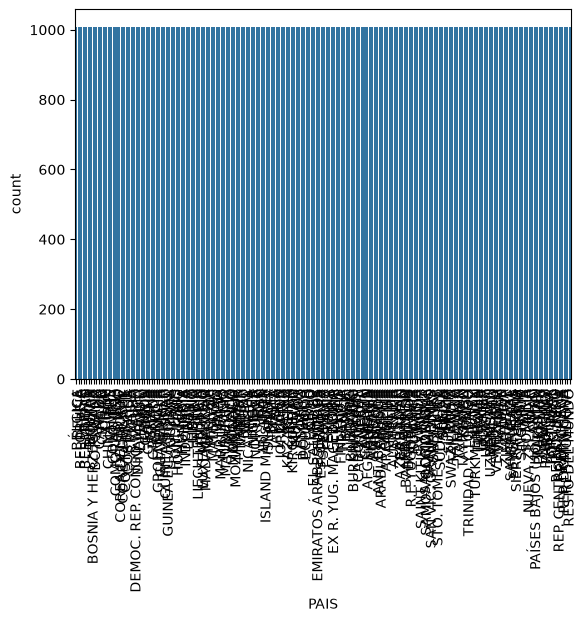

graph for DEPARTAMENTO_OCM: total = 5


C:\Users\JP\AppData\Local\Temp\ipykernel_7776\1230033410.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


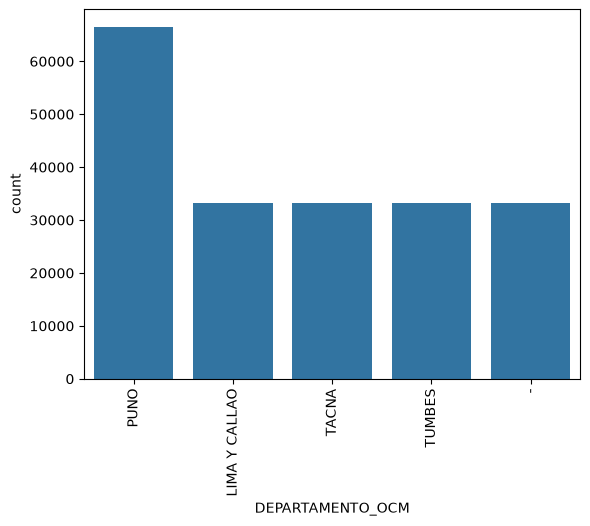

graph for CONTINENTE: total = 8


C:\Users\JP\AppData\Local\Temp\ipykernel_7776\1230033410.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


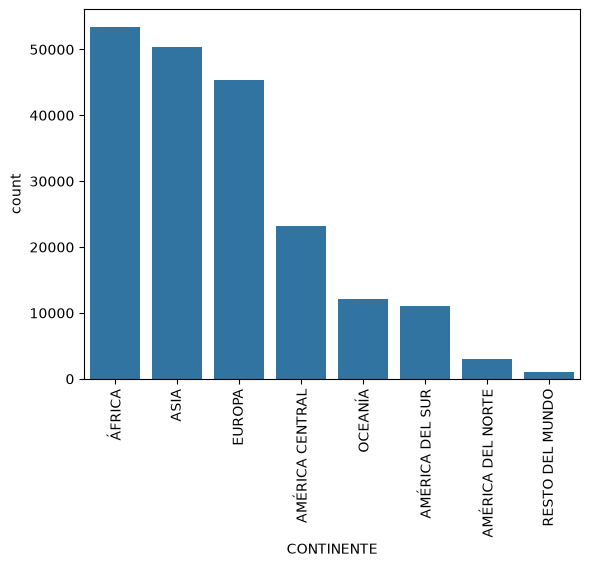

graph for OCM: total = 6


C:\Users\JP\AppData\Local\Temp\ipykernel_7776\1230033410.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


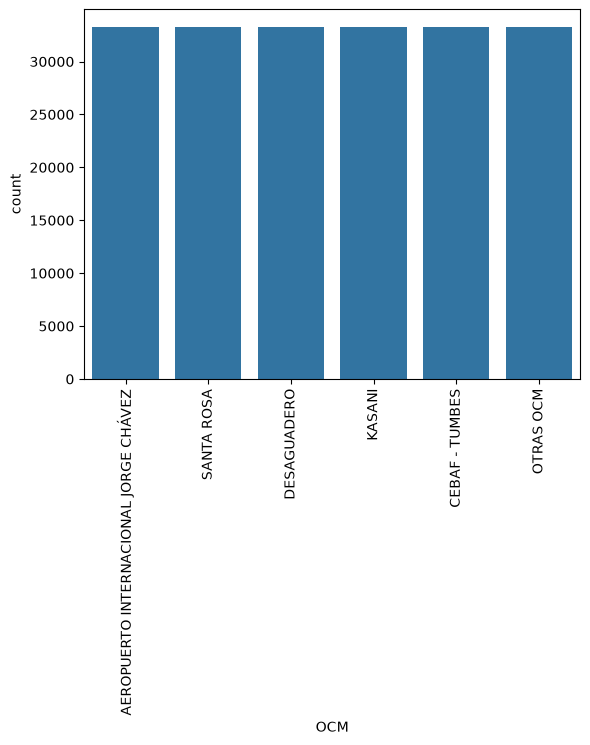

In [40]:
##### Analizando datos
#### Cuant
display(df_1[cuant_vars_1].describe())

#### Cual
for col in cual_vars_1:
    cat_num = df_1[col].value_counts()[:]
    print("graph for %s: total = %d" % (col, len(cat_num)))
    chart = sns.barplot(x=cat_num.index, y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

<Axes: >

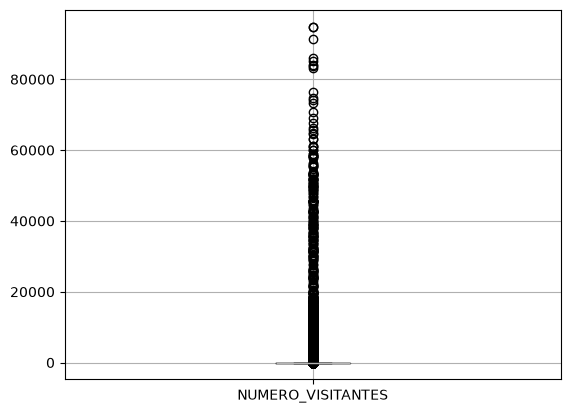

In [45]:
##### Analisis mas profundo
#### ANIO
# df_1['ANIO'].value_counts()

#### ID_MES
# df_1['ID_MES'].value_counts()

#### ID_PAIS
# df_1['ID_PAIS'].value_counts()
# len(df_1['ID_PAIS'].value_counts().to_dict().keys())

#### ID_CONTINENTE
# df_1['ID_CONTINENTE'].value_counts()

#### ID_OCM
# df_1['ID_OCM'].value_counts()

#### DEPARTAMENTO_OCM
# df_1['DEPARTAMENTO_OCM'].value_counts()

#### NUMERO_VISITANTES
# df_1['NUMERO_VISITANTES'].describe()
# df_1['NUMERO_VISITANTES'].value_counts()
# df_1.info()
# df_1[df_1['NUMERO_VISITANTES'] > 100].info()
# df_1[(df_1['NUMERO_VISITANTES'] <= 100) & (df_1['NUMERO_VISITANTES'] > 50)].info()
# df_1[(df_1['NUMERO_VISITANTES'] <= 50) & (df_1['NUMERO_VISITANTES'] > 25)].info()
# df_1[df_1['NUMERO_VISITANTES'] <= 25].info()
df_1.boxplot(column='NUMERO_VISITANTES')

<Axes: >

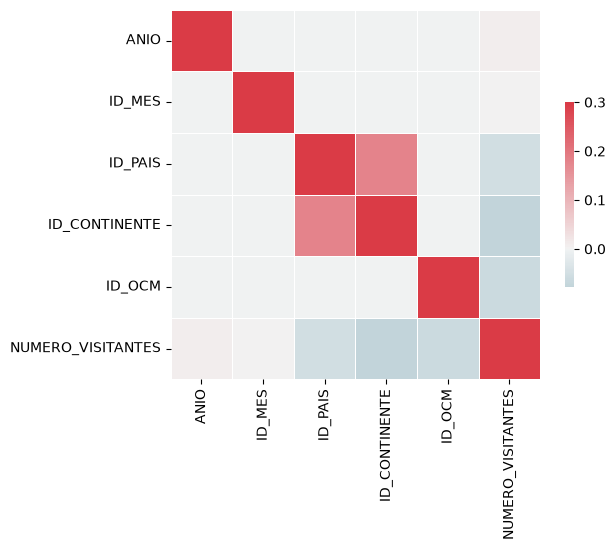

In [ ]:
##### Correlacion
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(df_1[cuant_vars_1].corr(),vmax=.3, center=0, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
    # Tecniamente no sirve correlacion pq solo hay una variable
            # realmente numerica
        # El resto de los variables son IDs

### Analisis de Datos 1

Analisis por columna:
* ANIO
    - Rango: 2019 - 2025
    - Hay 28512 registros en cada uno de los 7 anios
* ID_MES
    - Rango: 1 - 12
    - Hay 16632 registros en cada uno de los 12 meses
* ID_PAIS
    - Existen 198 distincto paises con valores de 1 - 198
    - Hay 1008 registros por cada pais
        - => Cada pais aparece 1008 veces en el conjunto
        - 7 anios * 12 meses * 6 OCMs * 2 tipos de visitantes = 1008
* PAIS
    - Nombre de los paises (1-1 correspondencia)
* ID_CONTINENTE
    - Existen 8 continentes 
    - Hay las siguiente variaciones:
        * Africa: 53424
        * Asia: 50400
        * Europa: 45360
        * America Central: 23184
        * Oceania: 12096
        * America del Sur: 11088
        * America del Norte: 3024
        * Resto: 1008
* CONTINENTE
    - Nombre de los id de los paises
* ID_OCM
    - Existen 6 OCMS
        * Aueropuerto Internacional (Lima)
            - Mapa: numero 106
        * Santa Rosa (Tacna)
            - Mapa: numero 66
        * Desguadero (Puno)
            - Mapa: numero 70
        * Kasani (Puno)
            - Mapa: numero 74
        * Cebaf-Tumbes (Tumbes)
            - Mapa: numero 13
        * Otras
    - Las 6 OCMs tienen 33264 registros cada una
* OCM
    * Nombres de los OCMs
* DEPARTAMENTO_OCM
    - Hay las siguiente variaciones:
        * Puno: 66528 = 33264 * 2
        * Lima y Callao: 33264
        * Tacna: 33264
        * Tumbes: 33264
        * Otros: 33264
* NUMERO_VISITANTES
    - Este es una columna extrana
    - (min, mean, median, max) = (0, 100, 0, 94883)
    - Estos datos son right skewed extremadamente
        * Evidencia: mean = 100 y median = 0
        * Significa que la mayoria de los datos seran outliers
    - Existen 199584 registros
        * 7732 registros tienen 'NUMERO_VISITANTES' > 100
        * 2261 registros tienen 'NUMER_VISITANTES' entre (50,100]
        * 3227 resgitros tienen 'NUMERO_VISITANTES' entre (25,50]
        * 185964 registros tienen 'NUMERO_VISITANTES' entre [0,25]
    - Detalle de frecuencias 'NUMERO_VISITANTES' en {0,1,2,3,4,5,6,7}
        * 0 visitantes: 158250 veces
        * 1 visitante: 7896 veces
        * 2 vistantes: 4056 veces
        * 3 visitantes: 2535 veces
        * 4-7 visitantes: entre 1000 - 2000 veces
        * 8 - 12 visitantes: entre 500 - 1000 veces
        * 13+ vistantes: menos de 500 veces
    - En otras palabras, la mayoria de los sitios turisticos solo tienen pocos visitantes
        * Tambien, esto es a traves de los 7 anios
        * Pero no cambia el hecho que la mayoria tienen 0 visitantes



#### EDA Datos 2: Visitantes a sitios

In [2]:
df_2 = pd.read_csv(nom_2)
df_2.head()

,ï»¿FECHA_CORTE,ANIO,ID_MES,MES,DEPARTAMENTO,SITIO_TURISTICO,TIPO_VISITANTE,NUMERO_VISITANTES
0,20260429,2019,1,ENERO,AMAZONAS,CAVERNA DE QUIOCTA,NACIONAL,448
1,20260429,2019,1,ENERO,AMAZONAS,CAVERNA DE QUIOCTA,EXTRANJERO,54
2,20260429,2019,1,ENERO,AMAZONAS,CAVERNA DE QUIOCTA,TOTAL,502
3,20260429,2019,1,ENERO,AMAZONAS,COMPLEJO ARQUEOLÃGICO DE KUÃLAP,NACIONAL,8928
4,20260429,2019,1,ENERO,AMAZONAS,COMPLEJO ARQUEOLÃGICO DE KUÃLAP,EXTRANJERO,1328


In [3]:
##### Resumen breve
df_2.info()
# df_2['TIPO_VISITANTE'].value_counts() #3: nacional, extranjero, total
# df_2['DEPARTAMENTO'].value_counts()
# len(df_2['DEPARTAMENTO'].value_counts().to_list())  #25
# len(df_2['SITIO_TURISTICO'].value_counts().to_list())   #156

##### Eliminando datos no necesarias
#### ELiminando columnas
df_2 = df_2.drop(columns=['ï»¿FECHA_CORTE', 'MES'])

#### Eliminando filas
df_2 = df_2[df_2['TIPO_VISITANTE'] == 'EXTRANJERO']
    # Despues de decir que todos los tipos son extranjeros,
            # se puede eliminar 'TIPO_VISITANTES'

df_2 = df_2.drop(columns=['TIPO_VISITANTE'])

<class 'pandas.DataFrame'>
RangeIndex: 36618 entries, 0 to 36617
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ï»¿FECHA_CORTE     36618 non-null  int64
 1   ANIO               36618 non-null  int64
 2   ID_MES             36618 non-null  int64
 3   MES                36618 non-null  str  
 4   DEPARTAMENTO       36618 non-null  str  
 5   SITIO_TURISTICO    36618 non-null  str  
 6   TIPO_VISITANTE     36618 non-null  str  
 7   NUMERO_VISITANTES  36618 non-null  int64
dtypes: int64(4), str(4)
memory usage: 2.2 MB


In [4]:
###### Separando variables categoricales y numericas
df_2.info()
cuant_vars_2 = ['NUMERO_VISITANTES']
cual_vars_2 = list(set(df_2.columns)- set(cuant_vars_2))
print(cuant_vars_2)
print(cual_vars_2)

<class 'pandas.DataFrame'>
Index: 12107 entries, 1 to 36616
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ANIO               12107 non-null  int64
 1   ID_MES             12107 non-null  int64
 2   DEPARTAMENTO       12107 non-null  str  
 3   SITIO_TURISTICO    12107 non-null  str  
 4   NUMERO_VISITANTES  12107 non-null  int64
dtypes: int64(3), str(2)
memory usage: 567.5 KB
['NUMERO_VISITANTES']
['ID_MES', 'SITIO_TURISTICO', 'DEPARTAMENTO', 'ANIO']


,NUMERO_VISITANTES
count,12107.000000
mean,3202.576526
std,11450.279033
min,0.000000
25%,0.000000
50%,44.000000
75%,582.500000
max,131500.000000


,NUMERO_VISITANTES,SITIO_TURISTICO
2902,131500,SANTUARIO HISTÃRICO DE MACHUPICCHU
34349,124266,SANTUARIO HISTÃRICO DE MACHUPICCHU
35568,123068,SANTUARIO HISTÃRICO DE MACHUPICCHU
3357,122868,SANTUARIO HISTÃRICO DE MACHUPICCHU
35163,122546,SANTUARIO HISTÃRICO DE MACHUPICCHU
...,...,...
23741,0,CENTRO ARQUEOLÃGICO INTIHUATANA
23747,0,MUSEO ARQUEÃLOGICO HIPÃLITO UNANUE
23750,0,MUSEO DE SITIO DE QUINUA
496,0,CONJUNTO ARQUEOLÃGICO DE SAYWITE


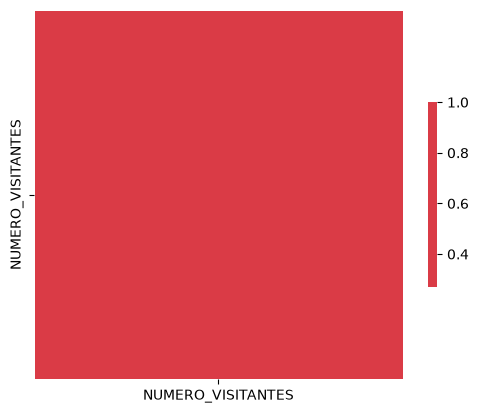

In [7]:
##### Analisis de datos cuantitativos
display(df_2[cuant_vars_2].describe())

##### Correlacion
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(df_2[cuant_vars_2].corr(),vmax=.3, center=0, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
    # Tecniamente no sirve correlacion pq solo hay una variable
            # realmente numerica
        # El resto de los variables son IDs

# df_2[['NUMERO_VISITANTES', 'SITIO_TURISTICO']].sort_values(by='NUMERO_VISITANTES', ascending=False)

graph for ID_MES: total = 12


C:\Users\JP\AppData\Local\Temp\ipykernel_4472\2278330572.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


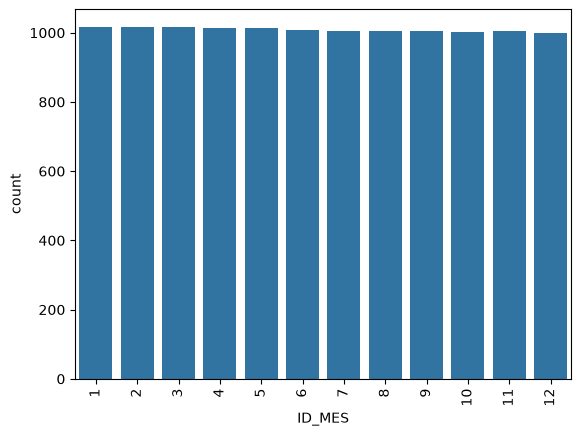

graph for SITIO_TURISTICO: total = 151


C:\Users\JP\AppData\Local\Temp\ipykernel_4472\2278330572.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
c:\Users\JP\Documents\DSProyectos\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\JP\Documents\DSProyectos\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\JP\Documents\DSProyectos\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 145 (\x91) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\JP\Documents\DSProyectos\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 129 (\x81) mis

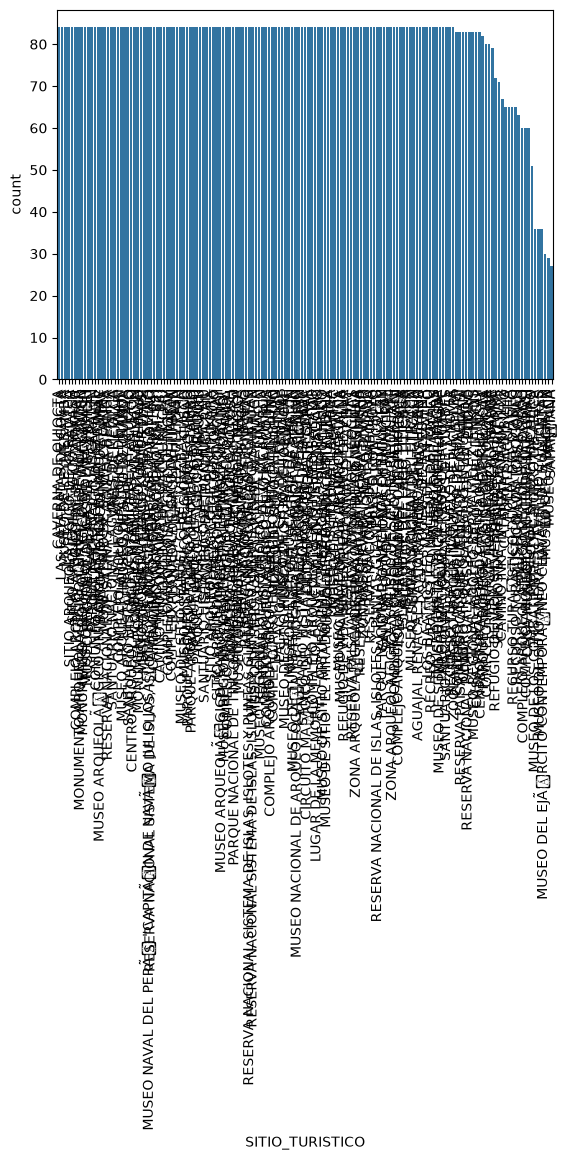

graph for DEPARTAMENTO: total = 25


C:\Users\JP\AppData\Local\Temp\ipykernel_4472\2278330572.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
c:\Users\JP\Documents\DSProyectos\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 141 (\x8d) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\JP\Documents\DSProyectos\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 129 (\x81) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


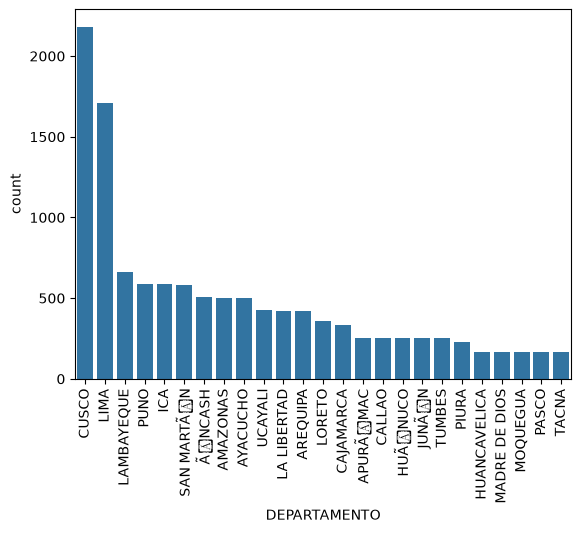

graph for ANIO: total = 7


C:\Users\JP\AppData\Local\Temp\ipykernel_4472\2278330572.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


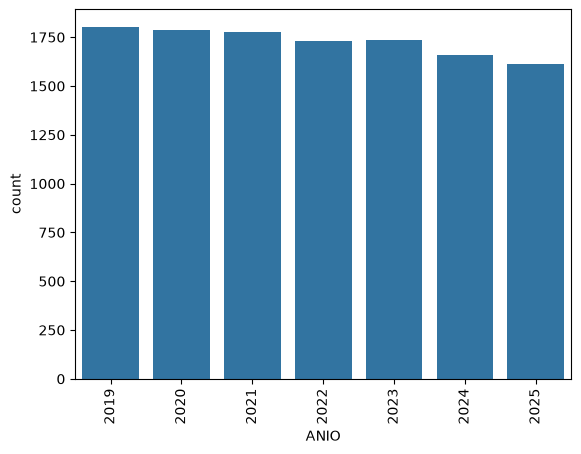

In [15]:
#### Analizando datos Cualitativos
for col in cual_vars_2:
    cat_num = df_2[col].value_counts()[:]
    print("graph for %s: total = %d" % (col, len(cat_num)))
    chart = sns.barplot(x=cat_num.index, y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

<Axes: >

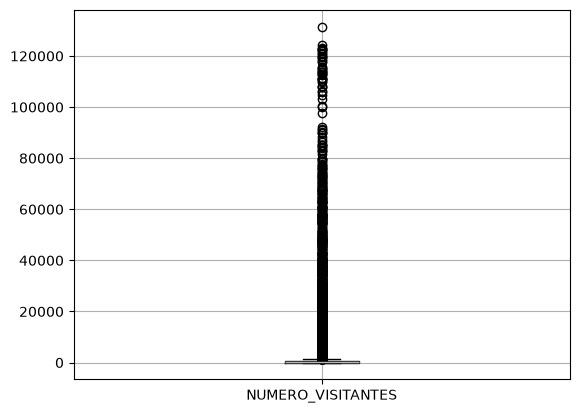

In [ ]:
##### Analisis mas profundo
#### ANIO
# df_2['ANIO'].value_counts(sort=False)

#### ID_MES
# df_2['ID_MES'].value_counts(sort=False)

#### DEPARTAMENTO
# df_2['DEPARTAMENTO'].value_counts()
# len(df_2['DEPARTAMENTO'].value_counts())

#### SITIO_TURISTICO
# df_2.info()
# counts = df_2['SITIO_TURISTICO'].value_counts().to_dict()
# print(len(counts))
# menos_84 = 0
# for k, v in counts.items(): 
#     if v < 84: menos_84+=1
# print(menos_84)

#### NUMERO_VISITANTES
# df_2['NUMERO_VISITANTES'].describe()
# df_2['NUMERO_VISITANTES'].value_counts()
# df_1.info()
# df_1[df_1['NUMERO_VISITANTES'] > 100].info()
# df_1[(df_1['NUMERO_VISITANTES'] <= 100) & (df_1['NUMERO_VISITANTES'] > 50)].info()
# df_1[(df_1['NUMERO_VISITANTES'] <= 50) & (df_1['NUMERO_VISITANTES'] > 25)].info()
# df_1[df_1['NUMERO_VISITANTES'] <= 25].info()
# df_2.boxplot(column='NUMERO_VISITANTES')


##### Analisis de Datos 2

Analisis por columna:
* ANIO
    - Rango: 2019 - 2025
    - Registros:
        * 2019: 1803 veces
        * 2020: 1787 veces
        * 2021: 1775 veces
        * 2022: 1731 veces
        * 2023: 1738 veces
        * 2024: 1660 veces
        * 2025: 1613 veces
* ID_MES
    - Rango: 1 - 12 (meses)
    - Registros: Estan entre 1000-1017 veces
* DEPARTAMENTO
    - Cantidad: 25 departamentos
    - Registros y variaciones:
        * Cusco = 2181
        * Lima = 1711
        * Resto = 660 o menos
* SITIO_TURISTICO
    - Cantidad: 151 sitios unicos
    - Registros y variaciones:
        * 121 sitios aparecen 84 veces
        * 30 sitios aparecen menos de 84 veces
* NUMERO_VISITANTES
    - Rango: 0 - 131500
    - (Min, mean, median, max) = (0, 3202.57, 44, 131500)
    - Registros:
        - 0 visitantes: 3383 veces
        - 1 - 6 visitantes: entre 112-155 veces
        - 7+ visitantes: menos de 100 veces

#### EDA 3: Inventarios de recursos turisticos

In [2]:
##### Cargando datos
df_3 = pd.read_csv(nom_3)
df_3.head()

,DEPARTAMENTO,PROVINCIA,DISTRITO,CODIGO DEL RECURSO,NOMBRE DEL RECURSO,CATEGORIA,TIPO_CATEGORIA,SUBTIPO_CATEGORIA,URL,LATITUD,LONGITUD,FECHA_DE_CORTE,TIPO,OBSERVACION,INGRESO
0,Cusco,Cusco,CUSCO,11,Festividad Del Señor De Los Temblores,5. ACONTECIMIENTOS PROGRAMADOS,Fiestas,Fiestas religiosas-patronales,https://consultasenlinea.mincetur.gob.pe/ficha...,-71.980100,-13.515300,20260727,Libre,Libre,0.0
1,Cajamarca,Contumaza,YONAN,16,Petroglifos De Yonan,2. MANIFESTACIONES CULTURALES,Sitios Arqueológicos,Petroglifos (Grabados en piedra),https://consultasenlinea.mincetur.gob.pe/ficha...,-79.130786,-7.253108,20260727,Libre,Libre,0.0
2,Amazonas,Chachapoyas,LEVANTO,17,Sitio Arqueológico De Collacruz,2. MANIFESTACIONES CULTURALES,Sitios Arqueológicos,Zonas arqueológicas,https://consultasenlinea.mincetur.gob.pe/ficha...,-77.907014,-6.310458,20260727,Libre,El recurso se encuentra junto a la carretera q...,0.0
3,Huánuco,Lauricocha,SAN MIGUEL DE CAURI,22,Laguna De Lauricocha,1. SITIOS NATURALES,g. Cuerpo de Agua,Lagunas,https://consultasenlinea.mincetur.gob.pe/ficha...,-76.663890,-10.315822,20260727,Previa presentación de boleto o ticket(especif...,Compra de boleto para acceso a tres atractivos...,5.0
4,Huánuco,Lauricocha,QUEROPALCA,24,Nevado De Yerupajá De Queropalca,1. SITIOS NATURALES,a. Montañas,Nevado,https://consultasenlinea.mincetur.gob.pe/ficha...,-76.905235,-10.268424,20260727,Previa presentación de boleto o ticket(especif...,"Se paga el ingreso al pueblo de Queropalca, S/...",35.0


In [6]:
##### Resumen breve
df_3.info()
# df_3['FECHA_DE_CORTE'].value_counts()
# df_3[df_3['INGRESO']== max(df_3['INGRESO'])]

#### Eliminando columnas que no son necesarias
df_3 = df_3.drop(columns=[
    'URL', 'FECHA_DE_CORTE', 'TIPO', 'OBSERVACION'
])



<class 'pandas.DataFrame'>
RangeIndex: 4556 entries, 0 to 4555
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DEPARTAMENTO        4556 non-null   str    
 1   PROVINCIA           4556 non-null   str    
 2   DISTRITO            4556 non-null   str    
 3   CODIGO DEL RECURSO  4556 non-null   int64  
 4   NOMBRE DEL RECURSO  4556 non-null   str    
 5   CATEGORIA           4556 non-null   str    
 6   TIPO_CATEGORIA      4556 non-null   str    
 7   SUBTIPO_CATEGORIA   4556 non-null   str    
 8   URL                 4556 non-null   str    
 9   LATITUD             4539 non-null   float64
 10  LONGITUD            4539 non-null   float64
 11  FECHA_DE_CORTE      4556 non-null   int64  
 12  TIPO                4556 non-null   str    
 13  OBSERVACION         4556 non-null   str    
 14  INGRESO             4556 non-null   float64
dtypes: float64(3), int64(2), str(10)
memory usage: 534.0 KB


In [ ]:
###### Separando variables categoricales y numericas
df_3.info()
    
cuant_vars_3 = df_3._get_numeric_data().columns.values
cual_vars_3 = list(set(df_3.columns)- set(cuant_vars_3))

<class 'pandas.DataFrame'>
RangeIndex: 4556 entries, 0 to 4555
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   DEPARTAMENTO        4556 non-null   str    
 1   PROVINCIA           4556 non-null   str    
 2   DISTRITO            4556 non-null   str    
 3   CODIGO DEL RECURSO  4556 non-null   int64  
 4   NOMBRE DEL RECURSO  4556 non-null   str    
 5   CATEGORIA           4556 non-null   str    
 6   TIPO_CATEGORIA      4556 non-null   str    
 7   SUBTIPO_CATEGORIA   4556 non-null   str    
 8   LATITUD             4539 non-null   float64
 9   LONGITUD            4539 non-null   float64
 10  INGRESO             4556 non-null   float64
dtypes: float64(3), int64(1), str(7)
memory usage: 391.7 KB


,CODIGO DEL RECURSO,LATITUD,LONGITUD,INGRESO
count,4556.000000,4539.000000,4539.000000,4556.000000
mean,9001.955663,-75.025957,-11.387859,2.173504
std,4843.959564,3.005434,3.522797,7.809398
min,11.000000,-81.325564,-18.296446,0.000000
25%,4215.500000,-77.100848,-13.667770,0.000000
50%,11384.500000,-75.379167,-12.058480,0.000000
75%,12952.500000,-72.533901,-9.179317,0.000000
max,14609.000000,-68.722645,-0.611103,91.666667


<Axes: >

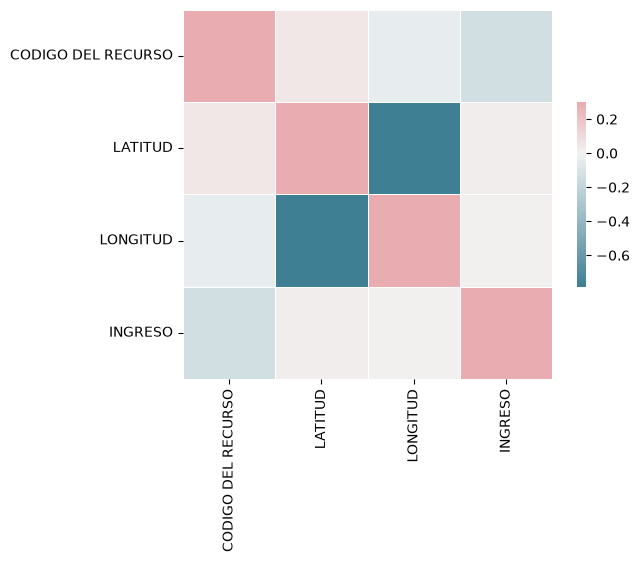

In [11]:
##### Analisis de datos cuantitativos
display(df_3[cuant_vars_3].describe())

##### Correlacion
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(df_3[cuant_vars_3].corr(),vmax=.3, center=0, cmap=cmap,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})
    # No existe mucha correlacion ya que los valores no tiene mucha conexion
        # LONG y LAT son los mas correlacionados

graph for SUBTIPO_CATEGORIA: total = 50


C:\Users\JP\AppData\Local\Temp\ipykernel_8748\2958786849.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


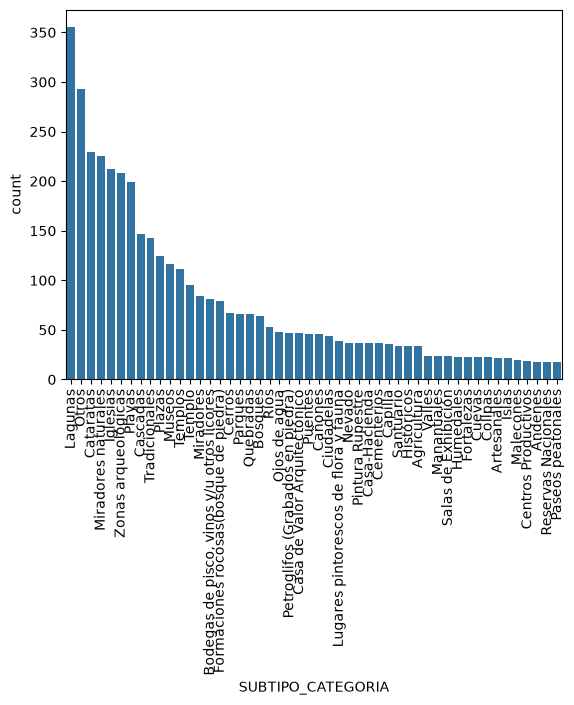

graph for DISTRITO: total = 50


C:\Users\JP\AppData\Local\Temp\ipykernel_8748\2958786849.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


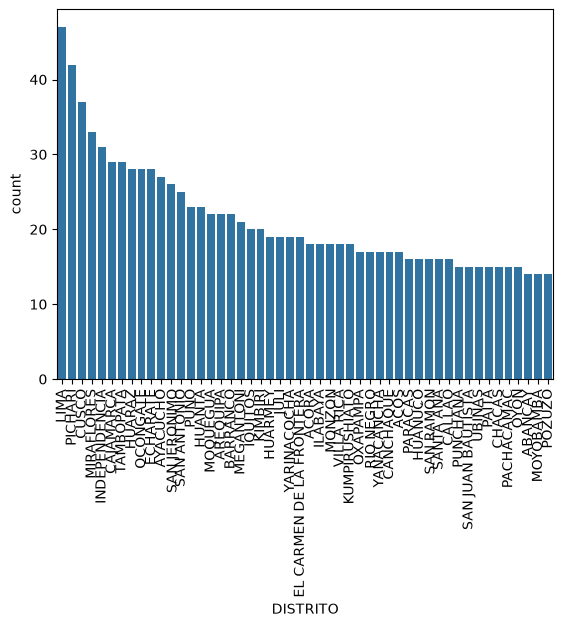

graph for CATEGORIA: total = 5


C:\Users\JP\AppData\Local\Temp\ipykernel_8748\2958786849.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


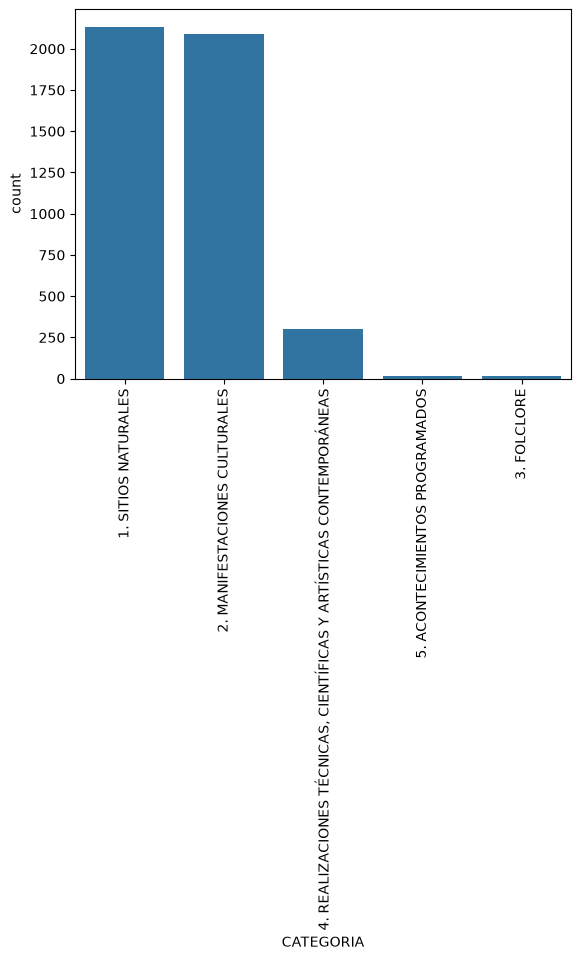

graph for TIPO_CATEGORIA: total = 35


C:\Users\JP\AppData\Local\Temp\ipykernel_8748\2958786849.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


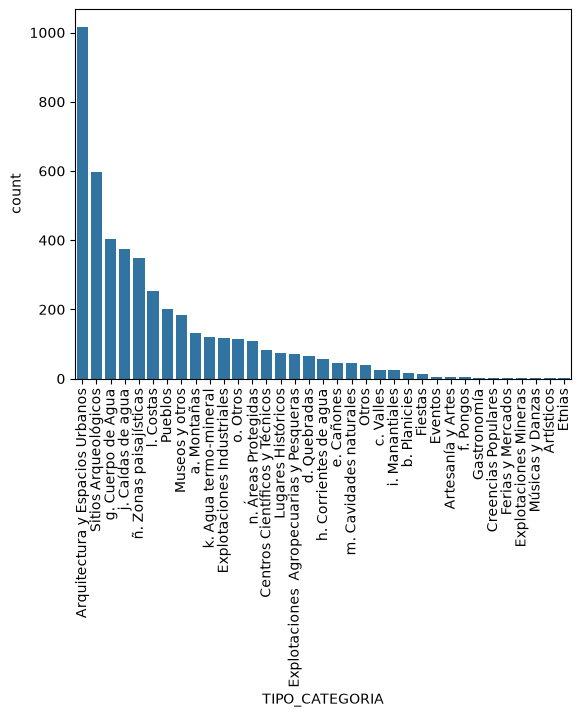

graph for DEPARTAMENTO: total = 25


C:\Users\JP\AppData\Local\Temp\ipykernel_8748\2958786849.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


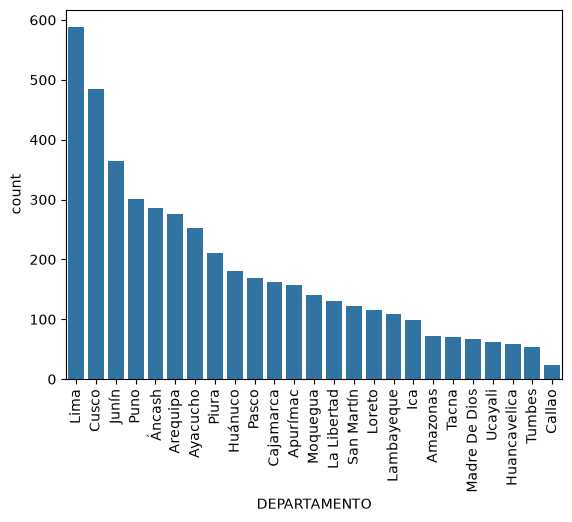

graph for PROVINCIA: total = 50


C:\Users\JP\AppData\Local\Temp\ipykernel_8748\2958786849.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


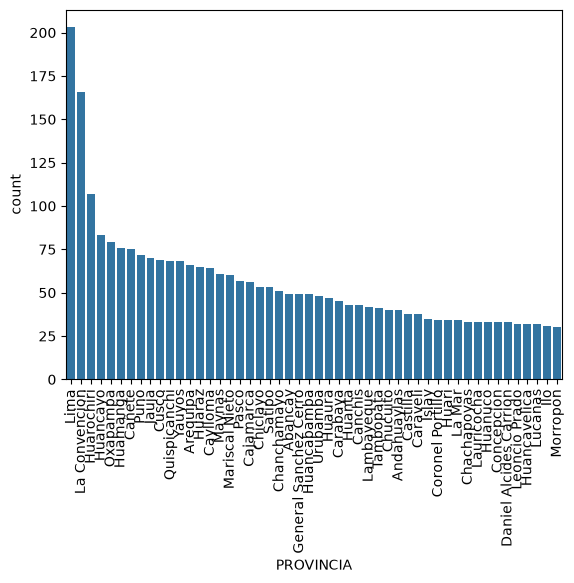

graph for NOMBRE DEL RECURSO: total = 50


C:\Users\JP\AppData\Local\Temp\ipykernel_8748\2958786849.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


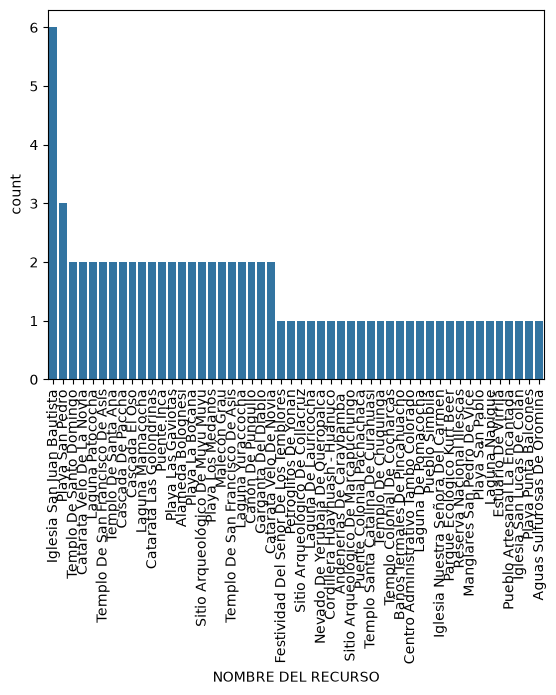

In [13]:
#### Analizando datos Cualitativos
for col in cual_vars_3:
    cat_num = df_3[col].value_counts()[:50]
    print("graph for %s: total = %d" % (col, len(cat_num)))
    chart = sns.barplot(x=cat_num.index, y=cat_num)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.show()

In [32]:
##### Analisis mas profundo
#### DEPARTAMENTO
# df_3['DEPARTAMENTO'].value_counts()

#### PROVINCIA
# df_3['PROVINCIA'].value_counts()

#### DISTRITO
# df_3['DISTRITO'].value_counts()

#### CODIGO DEL RECURSO
# df_3['CODIGO DEL RECURSO'].value_counts()
# df_3['CODIGO DEL RECURSO'].hist(figsize=(12,5),xrot=90, grid = False, edgecolor='black', bins = len(df_3['CODIGO DEL RECURSO'].to_list()))

#### NOMBRE DEL RECURSO
# df_3['NOMBRE DEL RECURSO'].value_counts()
# df_3[df_3['NOMBRE DEL RECURSO'] == 'Iglesia San Juan Bautista']

#### CATEGORIA
# df_3['CATEGORIA'].value_counts()

#### TIPO_CATEGORIA
# df_3['TIPO_CATEGORIA'].value_counts()

#### SUBTIPO_CATEGORIA
# df_3['SUBTIPO_CATEGORIA'].value_counts()

#### LATITUD
# df_3['LATITUD'].describe()
# df_3.boxplot(column='LATITUD')

#### LONGITUD
# df_3['LONGITUD'].describe()
# df_3.boxplot(column='LONGITUD')

#### INGRESO
df_3['INGRESO'].describe()

count    4556.000000
mean        2.173504
std         7.809398
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        91.666667
Name: INGRESO, dtype: float64

#### Analisis de Datos 3

Analisis por columna:
* DEPARTAMENTO
    - Todos los 25 departamentos de Peru se encuentran presentes
    - Variaciones entre departamentos:
        * Lima: 588 veces
        * Cusco: 485 veces
        * Junin: 364
        * Puno: 301
        * Piura, Ayacucho, Arequipa, Ancash: entre 200-300
        * Todos los demas: 181 veces o menos
* PROVINCIA
    - Existen 186 provincias presentes
    - Variaciones:
        * Lima: 203 veces
        * La convencion: 166
        * huarochiri: 107
        * Todos los demas: menos 83 o menos veces
* DISTRITO
    - Existen 932 distritos presentes
    - Variaciones: 
        * Max = 47 veces
        * Min = 1 vez
* CODIGO DEL RECURSO
    - Existen 4556 codigos => cada registro es un codigo diferente
    - Todos los codigos aparecen 1 vez
        * Pigeon-hole principal
* NOMBRE DEL RECURSO
    - Existen 4528 registros
    - La mayoria de ellos son unicos
    - Hay algunos repetidos pero es pq son recursos en diferentes lugares con el mismo nombre
* CATEGORIA
    - Existen 4 categorias:
        * Sitios naturales: 2134 veces
        * Manifestaciones culturales: 2089 veces
        * Realizaciones tecnicas: 300 veces
        * Acontecimientos programados: 19 veces
        * Folclore: 14 veces
* TIPO_CATEGORIA
    - Existen 35 tipos
    - Variaciones:
        * Arquitectura y espacios urbanos: 1017 veces
        * Sitios arqueologicos: 596 veces
        * Cuerpo de agua: 404 veces
        * Resto: 376 veces o menos
* SUBTIPO_CATEGORIA
    - Existen 169 subtipos
    - La mayoria se encuentran en: lagunas, otros, cataratas, miradores, iglesias, zonas arqueologicas, playas, cascadas
    - Existen subtipos que solo aparecen una vez
* LATITUD
    - Rango: -81.3255, -68.7226
* LONGITUD
    - Rango: -18.2964, -0.6111
* INGRESO
    - (min, mean, median, max): (0, 2.1735, 0, 91.67)
    - La mayoria son gratis, pero existen algunas que tienen precio alto